In [ ]:
# notebook magics
# inline/notebook/interactive
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os, sys
sys.path.append(os.path.abspath("lib")) # N.B: NB needs this line to run locally!!
# os.chdir("./3D")
os.getcwd()

'/home/mb3835/ps-model-exact/S_3D'

In [ ]:
from argparse import Namespace
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import xp

from IPython.display import display
# make figures higher resolution (larger)
plt.rcParams['figure.dpi'] = 100
# A decent backend for animations
plt.rcParams["animation.html"] = "jshtml"
# let 'em get big
plt.rcParams["animation.embed_limit"] = 100  # MB

# import our code that we need
import os, sys 
sys.path.append(os.path.abspath("lib")) # N.B: NB needs this line to run locally!!

import fixed_center_of_mass_exact_3D_S as fcm3S

os.chdir("../3D")
import fixed_center_of_mass_exact_3D as fcm3

ModuleNotFoundError: No module named 'xp'

In [59]:
base_params = {
        'g_1': 1.0, 'g_2': 1.0,
        'M_1': 2e3, 'M_2': 2e3,
        'NR': 21, 'Nr': 51, 'Ng': 21,
        'J': 0.5, 'potential': 'erf_coulomb',
        'preconditioner': 'naive',
        'verbosity': 0, 't': 64,
        'Nint':300, 'soc':'full', 'alpha':1e4,
    }
# base_params = {
#         'g_1': 0.5, 'g_2': 1.0,
#         'M_1': 1e6, 'M_2': 6,
#         'NR': 43, 'Nr': 41, 'Ng': 22,
#         'J': 0.5, 'potential': 'borgis',
#         'preconditioner': 'naive',
#         'Nint': 300,
#         'verbosity': 0, 't': 128
#     }
args = Namespace(**base_params)
HS = fcm3S.Hamiltonian(args)
args.soc=None
args.alpha=0
print(args)
HN = fcm3S.Hamiltonian(args)
# args.J = 0
# H3 = fcm3.Hamiltonian(args)
# args.J = 1
# HJ1 = fcm3.Hamiltonian(args)
# args.J = 2
# HJ2 = fcm3.Hamiltonian(args)
# args.J = 1.5
# H32 = fcm3S.Hamiltonian(args)

soc const, alpha, aa 0.2663967179924343 10000.0 5.623764682286852
Potential: erf_coulomb
extent in unscaled coords: [0.425 5.655] 12.308
extent in   scaled coords: [ 2.39009999 31.80238928] 2.188569525102367
min of Vgrid R -4.527810368234341 (np.int64(1), np.int64(0), np.int64(0))
[Build Vsph from Vgrid] Elapsed time: 9.06e+04us
Preconditioner requires 0MB.
[Build preconditioner naive] Elapsed time: 44.6us
Namespace(g_1=1.0, g_2=1.0, M_1=2000.0, M_2=2000.0, NR=21, Nr=51, Ng=21, J=0.5, potential='erf_coulomb', preconditioner='naive', verbosity=0, t=64, Nint=300, soc=None, alpha=0)
soc const, alpha, aa 0.0 0 5.623764682286852
Potential: erf_coulomb
extent in unscaled coords: [0.425 5.655] 12.308
extent in   scaled coords: [ 2.39009999 31.80238928] 2.188569525102367
min of Vgrid R -4.527810368234341 (np.int64(1), np.int64(0), np.int64(0))
[Build Vsph from Vgrid] Elapsed time: 1.61e+05us
Preconditioner requires 0MB.
[Build preconditioner naive] Elapsed time: 44.6us


In [60]:
Ad_vnS, U_nS, U_vS, Ad_nS = HS._build_preconditioner_BO()
Ad_vnN, U_nN, U_vN, Ad_nN = HN._build_preconditioner_BO()

Building U_n
[Build Hel] Elapsed time: 4.04e+06us
[Diag  Hel] Elapsed time: 1.72e+07us
[Phase match U_n] Elapsed time: 6.21e+05us
[Build Hbo] Elapsed time: 1.23e+03us
[Diag  Hbo] Elapsed time: 1e+05us
[Phase match U_v] Elapsed time: 4.43e+03us
Building U_n
[Build Hel] Elapsed time: 3.98e+06us
[Diag  Hel] Elapsed time: 1.72e+07us
[Phase match U_n] Elapsed time: 6.19e+05us
[Build Hbo] Elapsed time: 1.87e+03us
[Diag  Hbo] Elapsed time: 9.87e+04us
[Phase match U_v] Elapsed time: 4.47e+03us


-0.48188396740380135 -0.48188396740380135
Ad_vnN[0,:4].T =  [[-0.54035117 -0.53258918 -0.52527184 -0.51842267 -0.51209763]
 [-0.54017719 -0.53242355 -0.52511423 -0.51827226 -0.51195407]
 [-0.44061344 -0.43038251 -0.4206389  -0.41120332 -0.40218067]
 [-0.44057918 -0.43034422 -0.42059742 -0.41115935 -0.40213442]
 [-0.12170964 -0.11395621 -0.10636391 -0.09877675 -0.09125998]
 [-0.12170964 -0.11395621 -0.10636391 -0.09877674 -0.09125997]]
Ad_vnS[0,:4].T =  [[-0.54035117 -0.53258918 -0.52527184 -0.51842267 -0.51209763]
 [-0.54017719 -0.53242355 -0.52511423 -0.51827226 -0.51195407]
 [-0.44061344 -0.43038251 -0.4206389  -0.41120332 -0.40218067]
 [-0.44057918 -0.43034422 -0.42059742 -0.41115935 -0.40213442]
 [-0.12170964 -0.11395621 -0.10636391 -0.09877675 -0.09125998]
 [-0.12170964 -0.11395621 -0.10636391 -0.09877674 -0.09125997]]


/tmp/ipykernel_356886/948931272.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


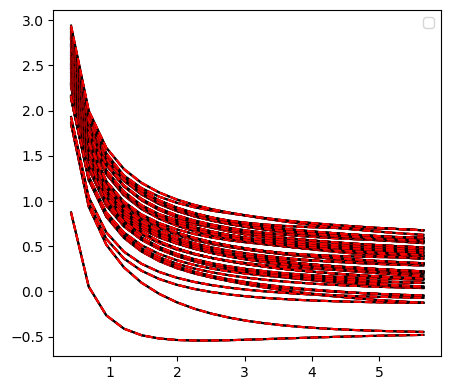

In [63]:
fig,ax = plt.subplots(figsize=(5,4.5))
n=0
for i in range(0,100):
    ax.plot(HN.R_lab, Ad_nN[:,i], color='k')#, label='None')
    ax.plot(HS.R_lab, Ad_nS[:,i], color='r', linestyle="--")
    
plt.legend()
# ax.set_ylim(xp.min(Ad_nN[:,0])-0.01,xp.min(Ad_nN[:,0])+0.1)

E0 = Ad_nN[-1,0]
E0_s = Ad_nS[-1,0]
print(E0, E0_s)
Eg = Ad_nN[:,0]
# print(HN.R_lab[np.argwhere(Eg-E0 < 1e-3)])
# print(HN.R_lab[0:4])
print("Ad_vnN[0,:4].T = ",Ad_vnN[:5,:6].T)
print("Ad_vnS[0,:4].T = ", Ad_vnS[:5,:6].T)

In [36]:
Ad_vnS, U_nS, U_vS, Ad_nS = HS._build_preconditioner_BO()
Ad_vn3, Un_3, U_v3, Ad_n3 = H3._build_preconditioner_BO()
Ad_vn1, Un_1, U_v1, Ad_n1 = HJ1._build_preconditioner_BO()
Ad_vn32, Un_32, U_v32, Ad_n32 = H32._build_preconditioner_BO()

Building U_n
[Build Hel] Elapsed time: 5.7e+06us
[Diag  Hel] Elapsed time: 1.29e+07us
[Phase match U_n] Elapsed time: 9.88e+05us
[Build Hbo] Elapsed time: 6.74e+03us
[Diag  Hbo] Elapsed time: 1.74e+06us
[Phase match U_v] Elapsed time: 1.58e+04us
Building U_n
[Build Hel] Elapsed time: 3.44e+05us
[Diag  Hel] Elapsed time: 2.48e+05us
[Phase match U_n] Elapsed time: 5.99e+04us
[Build Hbo] Elapsed time: 7.8e+02us
[Diag  Hbo] Elapsed time: 3.49e+05us
[Phase match U_v] Elapsed time: 3.02e+03us
Building U_n
[Build Hel] Elapsed time: 3.35e+06us
[Diag  Hel] Elapsed time: 5.6e+06us
[Phase match U_n] Elapsed time: 5.53e+05us
[Build Hbo] Elapsed time: 4.96e+03us
[Diag  Hbo] Elapsed time: 1.21e+06us
[Phase match U_v] Elapsed time: 6.38e+04us
Building U_n
[Build Hel] Elapsed time: 1.93e+07us
[Diag  Hel] Elapsed time: 1.03e+08us
[Phase match U_n] Elapsed time: 3.71e+06us
[Build Hbo] Elapsed time: 1.29e+04us
[Diag  Hbo] Elapsed time: 4.13e+06us
[Phase match U_v] Elapsed time: 7.49e+04us


In [46]:
Ad_vn2, U_n2, U_v2, Ad_n2 = HJ2._build_preconditioner_BO()


Building U_n
[Build Hel] Elapsed time: 5.3e+06us
[Diag  Hel] Elapsed time: 1.13e+07us
[Phase match U_n] Elapsed time: 9.62e+05us
[Build Hbo] Elapsed time: 7.75e+03us
[Diag  Hbo] Elapsed time: 2.04e+06us
[Phase match U_v] Elapsed time: 7.1e+04us


Ad_vnS[0,:4].T =  [[-0.01467622 -0.01294973 -0.01129751 -0.00971842 -0.00821067]
 [-0.01466847 -0.01294218 -0.01129021 -0.0097114  -0.00820396]
 [-0.01171475 -0.01010018 -0.00854539 -0.00704979 -0.00561035]
 [-0.01170803 -0.01009367 -0.00853913 -0.00704382 -0.0056047 ]
 [-0.00835324 -0.00678342 -0.00526568 -0.00380265 -0.00239164]
 [-0.00834312 -0.00677399 -0.00525694 -0.00379462 -0.0023843 ]]
Ad_vn3[0,:4].T =  [[-1.51232934e-02 -1.33914982e-02 -1.17319089e-02 -1.01431513e-02
  -8.62335014e-03]
 [-8.82302033e-03 -7.22954872e-03 -5.68429457e-03 -4.18972437e-03
  -2.74390265e-03]
 [-5.16667978e-03 -3.19706788e-03 -1.46546345e-03  9.49127227e-05
   1.63112354e-03]
 [-2.92654572e-03 -1.21319785e-03  5.45805358e-04  2.23874984e-03
   3.85953896e-03]
 [ 9.81219969e-04  2.42881104e-03  3.87069685e-03  5.28708662e-03
   6.69197951e-03]
 [ 2.88224952e-03  4.80685914e-03  6.27830397e-03  7.65390613e-03
   9.06759478e-03]]
<R> =  2.3785556478658365
\sqrt{<R^2>} =  2.3809951215404155


(-0.02, 0.02)

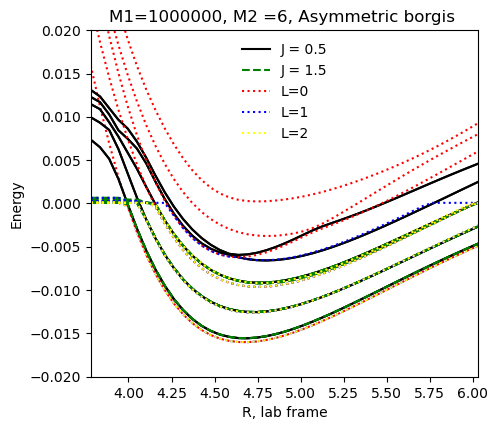

In [44]:
fig,ax = plt.subplots(figsize=(5,4.5))
n=0
print("Ad_vnS[0,:4].T = ",Ad_vnS[:5,:6].T)
print("Ad_vn3[0,:4].T = ", Ad_vn3[:5,:6].T)

# print("Ad_vn[1,:4].T = ",Ad_vn[1,:4].T)
# print("min", np.argmin(Ad_n[:,0]), H.R_lab[np.argmin(Ad_n[:,0])])
ax.plot(HS.R_lab, Ad_nS[:,0], color='k', label="J = 0.5")
ax.plot(HS.R_lab, Ad_n32[:,0], color='g',linestyle='--', label="J = 1.5")
ax.plot(H3.R_lab, Ad_n3[:,0], color='r', linestyle=":", label="L=0")
ax.plot(H3.R_lab, Ad_n1[:,0], color='b', linestyle=":", label="L=1")
ax.plot(H3.R_lab, Ad_n1[:,0], color='yellow', linestyle=":", label="L=2")


for i in range(1,10):
    ax.plot(HS.R_lab, Ad_nS[:,i], color='k')
    ax.plot(H32.R_lab, Ad_n32[:,i], color='g', linestyle='--')
for i in range(1,5):
    ax.plot(H3.R_lab, Ad_n3[:,i], color='r', linestyle=":")
    ax.plot(HJ1.R_lab, Ad_n1[:,i], color='b', linestyle=":")
    ax.plot(HJ2.R_lab, Ad_n2[:,i], color='yellow', linestyle=":")

# ax.plot(H.R_lab, U_v[n,:,0]*0.01 + np.min(Ad_n[:,n]), label="Vib on 0")
# ax.plot(H.R_lab, U_v[n,:,1]*0.01 + np.min(Ad_n[:,n]))
# ax.plot(H.R_lab, U_v[n,:,2]*0.01 + np.min(Ad_n[:,n]))
# ax.plot(H.R_lab, U_v[n,:,0]*1 + np.min(Ad_n[:,n]), label="Vib on 0")
# ax.plot(H.R_lab, U_v[n,:,1]*1 + np.min(Ad_n[:,n]))
# ax.plot(H.R_lab, U_v[n,:,2]*1 + np.min(Ad_n[:,n]))
# ax.plot(H.R_lab, U_v[n,:,3]*2 + np.min(Ad_n[:,n]))
# ax.plot(H.R_lab, U_v[n,:,4]*2 + np.min(Ad_n[:,n]))
# ax.plot(H.R_lab, Ad_n[:,0])
# ax.plot(H.R_lab, Ad_n[:,1], c='r', linestyle='--', label="BO excited") 
# for j in range(10):
#     ax.plot(H.R_lab, Ad_n[:,j], c='r', linestyle='--')
# ax.plot(H.R_lab, (Ad_n[:,n]), color='k', label="BO 0", linestyle='--')
ax.set_xlabel("R, lab frame")
ax.set_ylabel("Energy")
ax.set_title("M1={:.0f}, M2 ={:.0f}, Asymmetric borgis ".format(args.M_1, args.M_2))
print("<R> = ", np.sum(U_v[0,:,0]*H.R_lab*U_v[0,:,0]))
print(r"\sqrt{<R^2>} = ", np.sqrt(np.sum(U_v[0,:,0]*(H.R_lab**2)*U_v[0,:,0])))
ax.legend(frameon=False)
ax.set_xmargin(0)
# ax.set_ylim(-1.5,1)
ax.set_ylim(-0.02,0.02)
# display(fig)

Building U_n
[Build Hel] Elapsed time: 1.7e+05us
[Diag  Hel] Elapsed time: 1.97e+05us
[Phase match U_n] Elapsed time: 3.73e+04us
[Build Hbo] Elapsed time: 2.45e+03us
[Diag  Hbo] Elapsed time: 4.51e+05us
[Phase match U_v] Elapsed time: 4.23e+03us


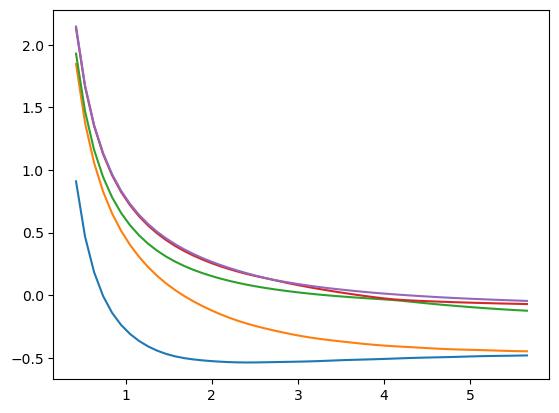

In [70]:
fig,ax =plt.subplots()
Ad_vn3, Un_3, U_v3, Ad_n3 = H3._build_preconditioner_BO()
for i in range(5):
    plt.plot(H3.R_lab, Ad_n3[:,i])